# Study 3 — judge panels across budget regimes (appendix G.4.2)

Does a cheap, small-model-only judge panel, put through the same DIAL calibration as every
other real-data result, match human-only evaluation and a large or full panel? And how does
the answer move as either budget — human labels or LLM comparisons — becomes the scarce one?

Three figures, one 3 × 3 grid (datasets × judge panels) in each:

| Figure | Sweep | Fixed |
|---|---|---|
| `fig_small_panel` | human budget $n_H$ | as-collected LLM data |
| `fig_small_panel_llmbudget` | LLM budget $n_L$ | $n_H = 300 / 80 / 60$ |
| `fig_intermediate_budget` | human budget $n_H$ | $n_L = 2000 / 160 / 100$ |

Panels: `small6` (six open-weight judges, ≤ 9B each, 36.5B total), `large6` (≥ 20B each,
203B total), `all` (the paper's 21-judge panel). Methods: Human, Cons-Cal, DIAL-$\mu$ (raw)
= the plain GACV minimizer, and DIAL-$\mu$ = the $1/n_H$ endpoint margin.

Data generation lives in the runners, not here:

```bash
python -m experiments.real_data.endpoint_margin --seeds 50 --workers 6 \
    --panels all small6 large6 --out results/endpoint_margin_appendix
python -m experiments.real_data.intermediate_budget --seeds 50 --workers 8 \
    --out /tmp/dial-intermediate-budget-50
python -m experiments.real_data.intermediate_budget_validate --root /tmp/dial-intermediate-budget-50
```

The same 50 record splits underlie all three figures, so the panels are directly comparable.
`python -m experiments.real_data.panel_budget --figures all` writes the same PDFs headlessly.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))

from experiments.real_data.panel_budget import (
    DATASET_LABEL, INTERMEDIATE_NL, METHODS, RCPARAMS, ROOT,
    intermediate_data, panel_budget_data, panel_grid,
)

FIGURES = REPO / "figures"
MARGIN_ROOT = ROOT / "results" / "endpoint_margin_appendix"
INTERMEDIATE_ROOT = ROOT / "results" / "intermediate_budget"

summary = panel_budget_data(MARGIN_ROOT)          # checks every cell carries all 50 seeds
intermediate, seeds = intermediate_data(INTERMEDIATE_ROOT)
print(f"{len(summary)} budget/llm_budget rows, {len(intermediate)} intermediate rows ({seeds} seeds)")

408 budget/llm_budget rows, 171 intermediate rows (50 seeds)


## Human budget at the collected LLM data

Where the small panel does and does not close the gap to `large6`, `all`, and human-only.

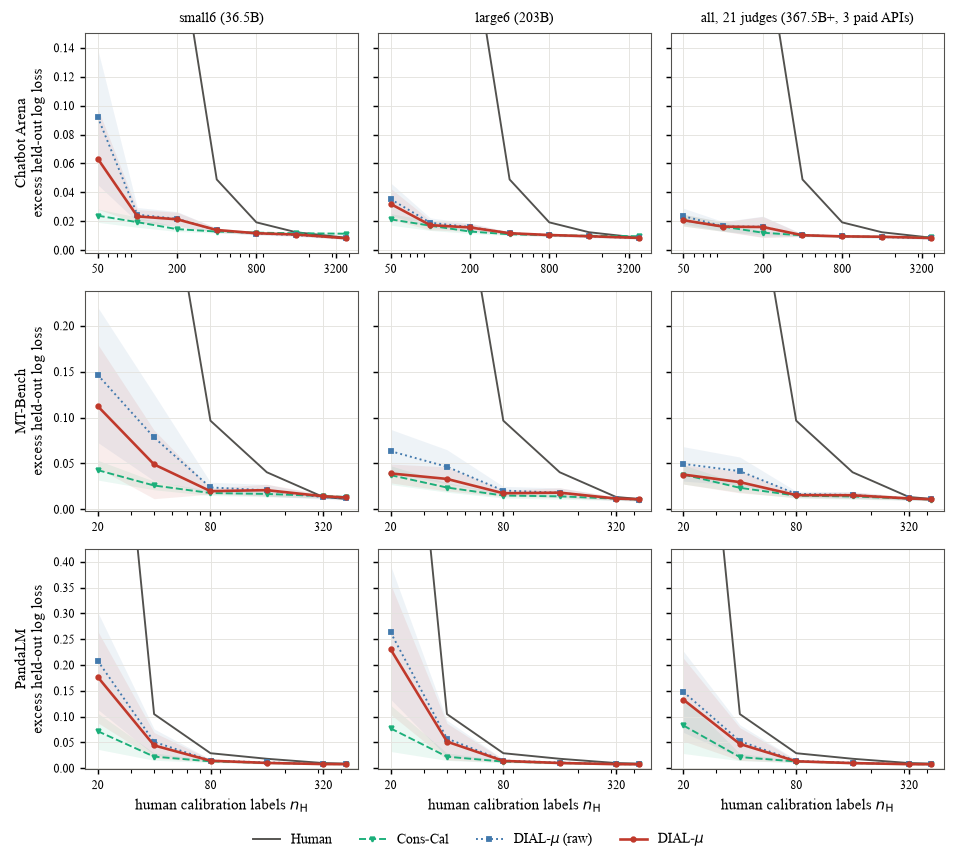

In [2]:
with plt.rc_context(RCPARAMS):
    rows = summary[summary.sweep == "budget"]
    fig = panel_grid(rows, "n_H", lambda ds: f"{DATASET_LABEL[ds]}\nexcess held-out log loss",
                     r"human calibration labels $n_{\mathrm{H}}$", METHODS)
    fig.savefig(FIGURES / "fig_small_panel.pdf", bbox_inches="tight")
    plt.show()

## LLM budget at the default human budget

The reverse constraint: an imprecise LLM-only direction limits Cons-Cal, while DIAL-$\mu$ can
re-estimate $\mu$ from the human comparisons.

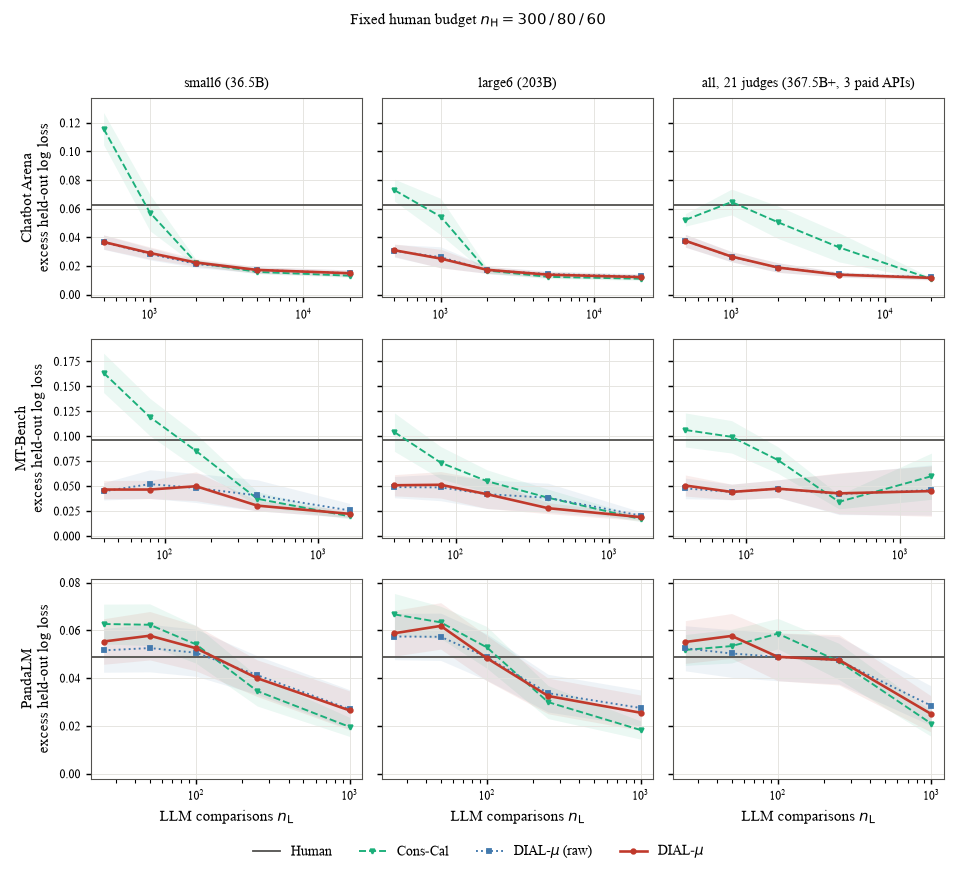

In [3]:
with plt.rc_context(RCPARAMS):
    rows = summary[summary.sweep == "llm_budget"]
    fig = panel_grid(rows, "level", lambda ds: f"{DATASET_LABEL[ds]}\nexcess held-out log loss",
                     r"LLM comparisons $n_{\mathrm{L}}$", METHODS, flat=("human_only",),
                     suptitle=r"Fixed human budget $n_{\mathrm{H}}=300\,/\,80\,/\,60$", xticks=False)
    fig.savefig(FIGURES / "fig_small_panel_llmbudget.pdf", bbox_inches="tight")
    plt.show()

## Human budget at a fixed intermediate LLM budget

The middle LLM level of the sweep above, which exposes the crossover between keeping the
LLM-only consensus direction (Cons-Cal) and letting human comparisons update it (DIAL-$\mu$).

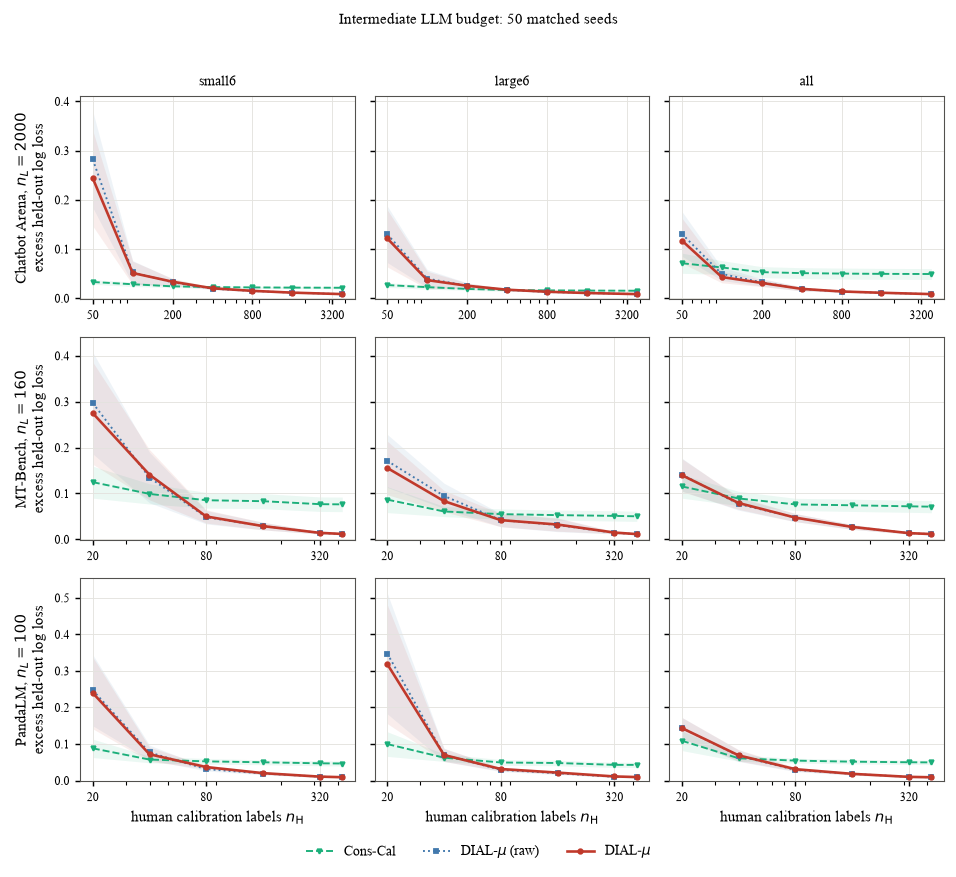

In [4]:
with plt.rc_context(RCPARAMS):
    fig = panel_grid(intermediate, "n_H",
                     lambda ds: f"{DATASET_LABEL[ds]}, $n_L={INTERMEDIATE_NL[ds]}$\nexcess held-out log loss",
                     r"human calibration labels $n_{\mathrm{H}}$", METHODS[1:],
                     titles=["small6", "large6", "all"],
                     suptitle=f"Intermediate LLM budget: {seeds} matched seeds")
    fig.savefig(FIGURES / "fig_intermediate_budget.pdf", bbox_inches="tight")
    plt.show()

## Descriptive crossover locations

The first tested human budget at which DIAL-$\mu$ beats Cons-Cal by more than two paired Monte
Carlo standard errors, and keeps doing so at every higher budget (appendix Table 3). A post hoc
summary of these curves, not a calibrated test or a switching rule for new data.

In [5]:
def crossover(frame):
    out = []
    for (ds, panel), g in frame.groupby(["dataset", "panel"]):
        g = g.sort_values("n_H")
        wins = g[g.method == "dial_margin_1"].set_index("n_H").delta_vs_cons
        mcse = g[g.method == "dial_margin_1"].set_index("n_H").paired_mcse
        better = (wins < -2 * mcse)
        first = next((n for n in better.index if better.loc[n:].all()), None)
        out.append(dict(dataset=ds, panel=panel, n_L=INTERMEDIATE_NL[ds], crossover_n_H=first))
    return pd.DataFrame(out)

crossover(intermediate).pivot(index="dataset", columns="panel", values="crossover_n_H")

panel,all,large6,small6
dataset,,,
arena_33k,100.0,800.0,400.0
mt_bench,80.0,160.0,80.0
pandalm,80.0,80.0,80.0
